In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import numpy as np

In [2]:
csv_path = Path('/home/filipepimentel/Desktop/Thesis code/lyrics_twitter_final.csv')
analysis_df = pd.read_csv(csv_path)
analysis_df.head()

,artist,title,disorder,bert_emotion,bert_confidence,lyrics_clean,go_multi_labels,go_multi_scores,go_emotion,go_confidence,go_valence,go_arousal,vad_valence,vad_arousal,va_distance,valence,arousal
0,Quadeca,Burnin Bridges / Long Day (feat. IDK),depression,joy,0.983130,Highest To Lowest: Quadeca LyricsQuadeca's Son...,disappointment,disappointment:0.0380,neutral,0.7992,-0.0373,0.0370,5.2587,5.6958,7.750460,0.300440,0.333046
1,Tom Jones,She's A Lady,control,joy,0.503159,She's a Lady Lyrics Well she's all you'd ever ...,admiration | approval,admiration:0.7320 | approval:0.2649,admiration,0.7320,0.7431,0.3167,5.4373,6.1020,7.450182,0.263476,0.375775
2,David Byrne,Lilies of the Valley,control,sadness,0.994102,Lilies of the Valley Lyrics Momma she had comp...,approval,approval:0.0948,neutral,0.6730,0.0757,0.0733,4.3560,5.9713,7.287481,0.344658,0.199640
3,Alice Cooper,School's Out,control,sadness,0.925512,"School's Out Lyrics Well, we got no choice All...",annoyance | disappointment | disapproval,annoyance:0.1691 | disappointment:0.1335 | dis...,neutral,0.5905,-0.2450,0.0458,4.1307,5.8503,7.269042,-0.703709,-0.349047
4,Alice Cooper,School's Out,control,sadness,0.925512,"School's Out Lyrics Well, we got no choice All...",annoyance | disappointment | disapproval,annoyance:0.1691 | disappointment:0.1335 | dis...,neutral,0.5905,-0.2450,0.0458,4.1307,5.8503,7.269042,-0.703709,-0.349047


In [3]:
cols = ['artist', 'title', 'disorder', 'vad_valence', 'vad_arousal', 'va_distance']
analysis_df = analysis_df[cols].drop_duplicates().reset_index(drop=True)
print(analysis_df.head())
print(analysis_df.info())
print(analysis_df.describe())

         artist                                  title    disorder  \
0       Quadeca  Burnin Bridges / Long Day (feat. IDK)  depression   
1     Tom Jones                           She's A Lady     control   
2   David Byrne                   Lilies of the Valley     control   
3  Alice Cooper                           School's Out     control   
4  Shawn Mendes                        Call My Friends  depression   

   vad_valence  vad_arousal  va_distance  
0       5.2587       5.6958     7.750460  
1       5.4373       6.1020     7.450182  
2       4.3560       5.9713     7.287481  
3       4.1307       5.8503     7.269042  
4       5.1058       5.7911     7.452654  
<class 'pandas.DataFrame'>
RangeIndex: 51600 entries, 0 to 51599
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   artist       51600 non-null  str    
 1   title        51600 non-null  str    
 2   disorder     51600 non-null  str    
 3   vad_valen

In [4]:
numeric_cols = analysis_df.select_dtypes(include=[np.number]).columns.tolist()
print('Numeric columns:', numeric_cols)
scaler = MinMaxScaler(feature_range=(-1, 1))
analysis_df[['vad_valence', 'vad_arousal']] = scaler.fit_transform(analysis_df[['vad_valence', 'vad_arousal']])
analysis_df.head()

Numeric columns: ['vad_valence', 'vad_arousal', 'va_distance']


,artist,title,disorder,vad_valence,vad_arousal,va_distance
0,Quadeca,Burnin Bridges / Long Day (feat. IDK),depression,0.119019,-0.123683,7.750460
1,Tom Jones,She's A Lady,control,0.186845,0.098030,7.450182
2,David Byrne,Lilies of the Valley,control,-0.223796,0.026691,7.287481
3,Alice Cooper,School's Out,control,-0.309357,-0.039354,7.269042
4,Shawn Mendes,Call My Friends,depression,0.060952,-0.071666,7.452654


# Plots for the whole dataset

Summary table per disorder:
                n  valence_mean  valence_std  valence_skew  arousal_mean  \
disorder                                                                   
control     33223       -0.0704       0.2250        0.2231        0.0439   
depression   6693       -0.0641       0.2319        0.0981        0.0482   
ptsd         4477       -0.0500       0.2343        0.1684        0.0493   
bipolar      3184       -0.0619       0.2353        0.1851        0.0485   
anxiety      2963       -0.0741       0.2321        0.1774        0.0507   
borderline    677       -0.1100       0.2448        0.1607        0.0575   
panic         383       -0.0961       0.2365        0.2491        0.0757   

            arousal_std  arousal_skew  distance_mean  distance_std  \
disorder                                                             
control          0.1840        0.0219         7.4769        0.3389   
depression       0.1896        0.0166         7.4795        0.3555   
ptsd   

/tmp/ipykernel_2175047/3567209215.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


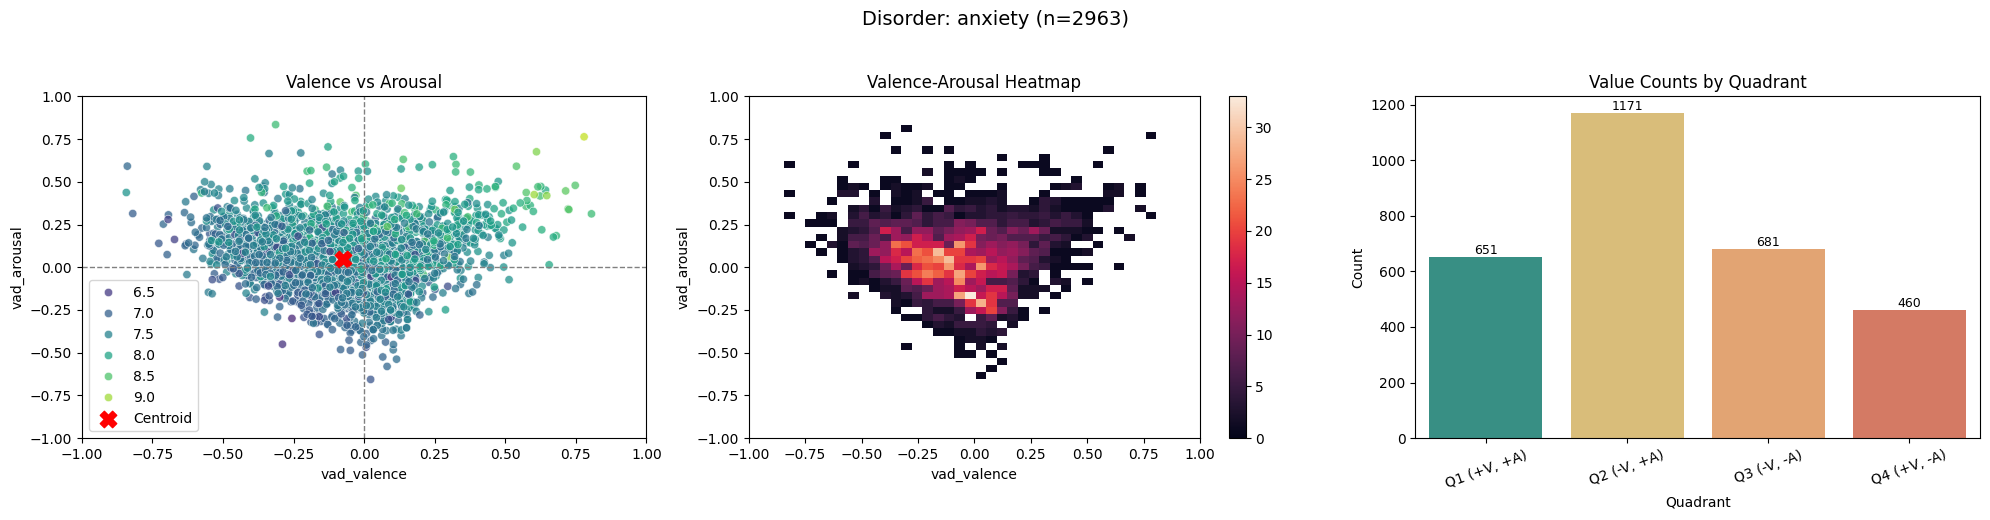

/tmp/ipykernel_2175047/3567209215.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


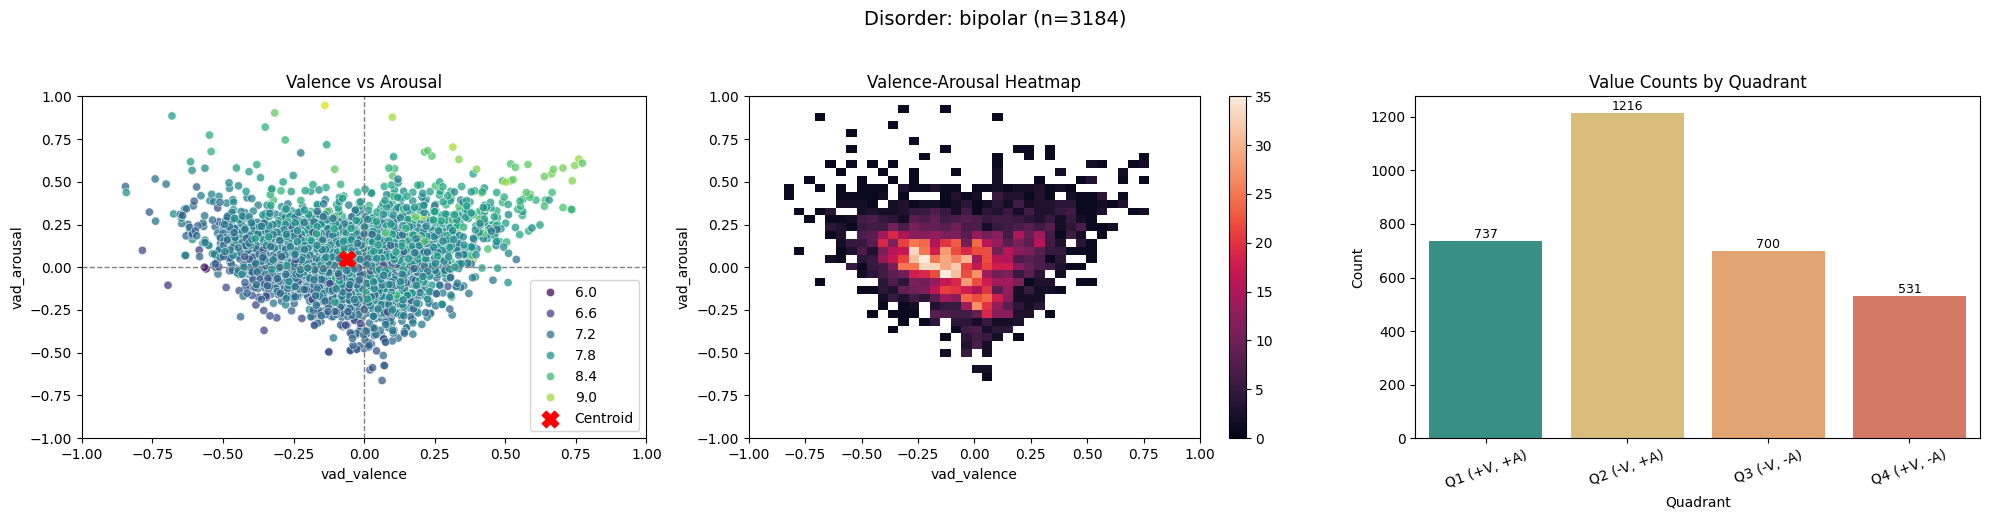

/tmp/ipykernel_2175047/3567209215.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


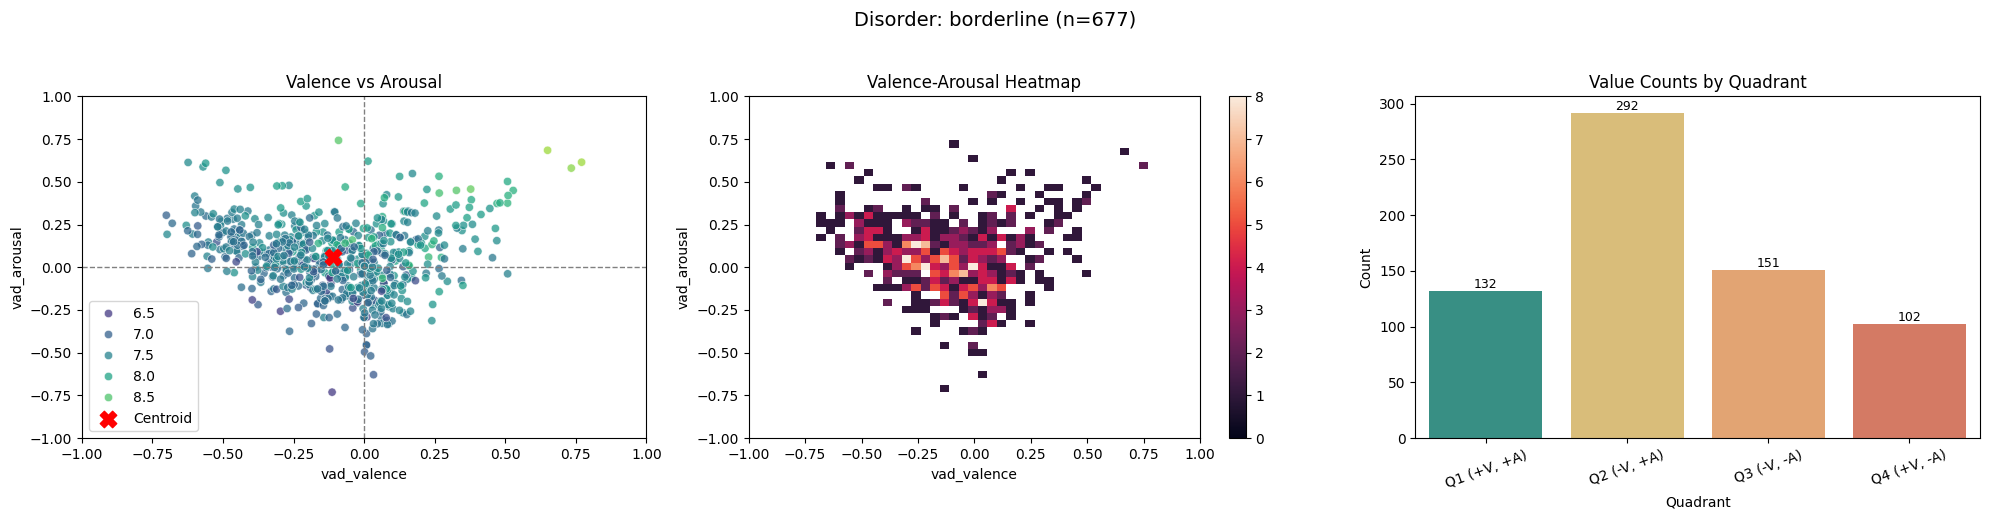

/tmp/ipykernel_2175047/3567209215.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


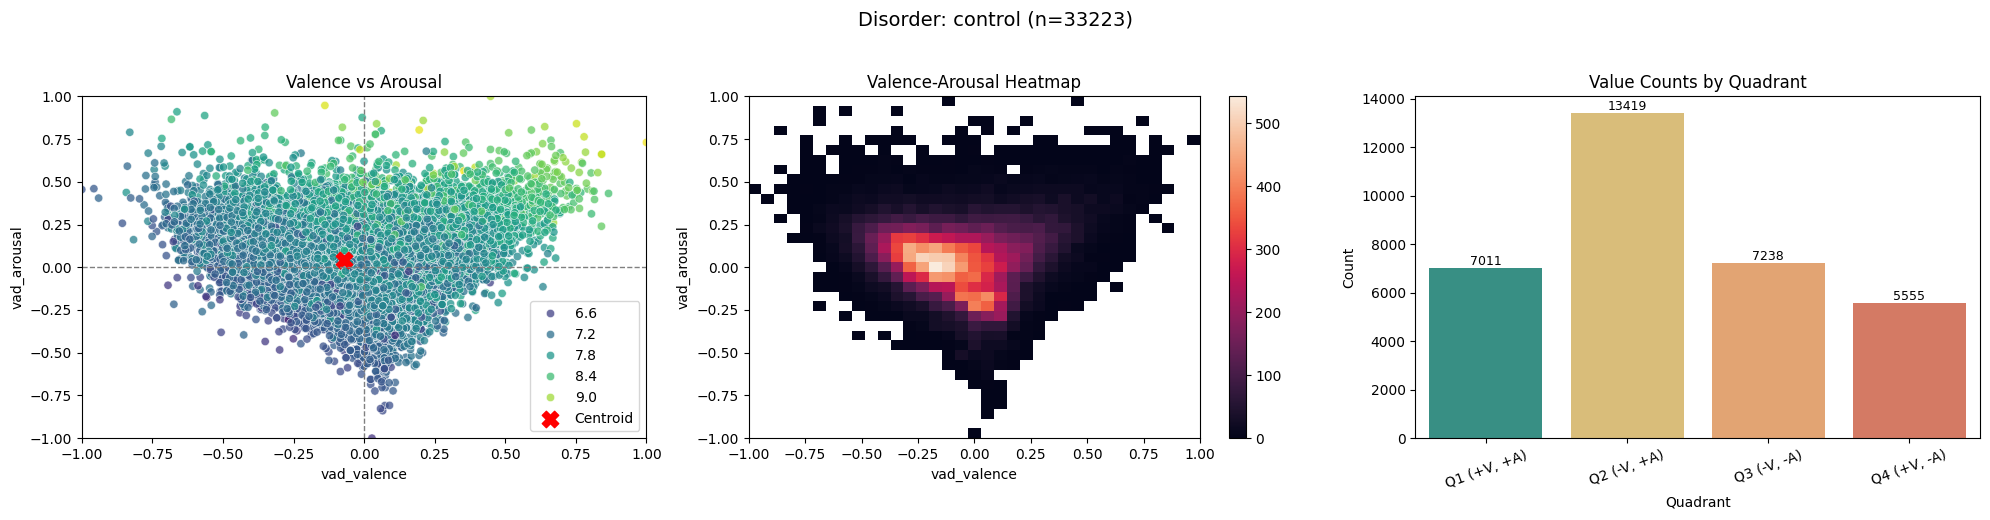

/tmp/ipykernel_2175047/3567209215.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


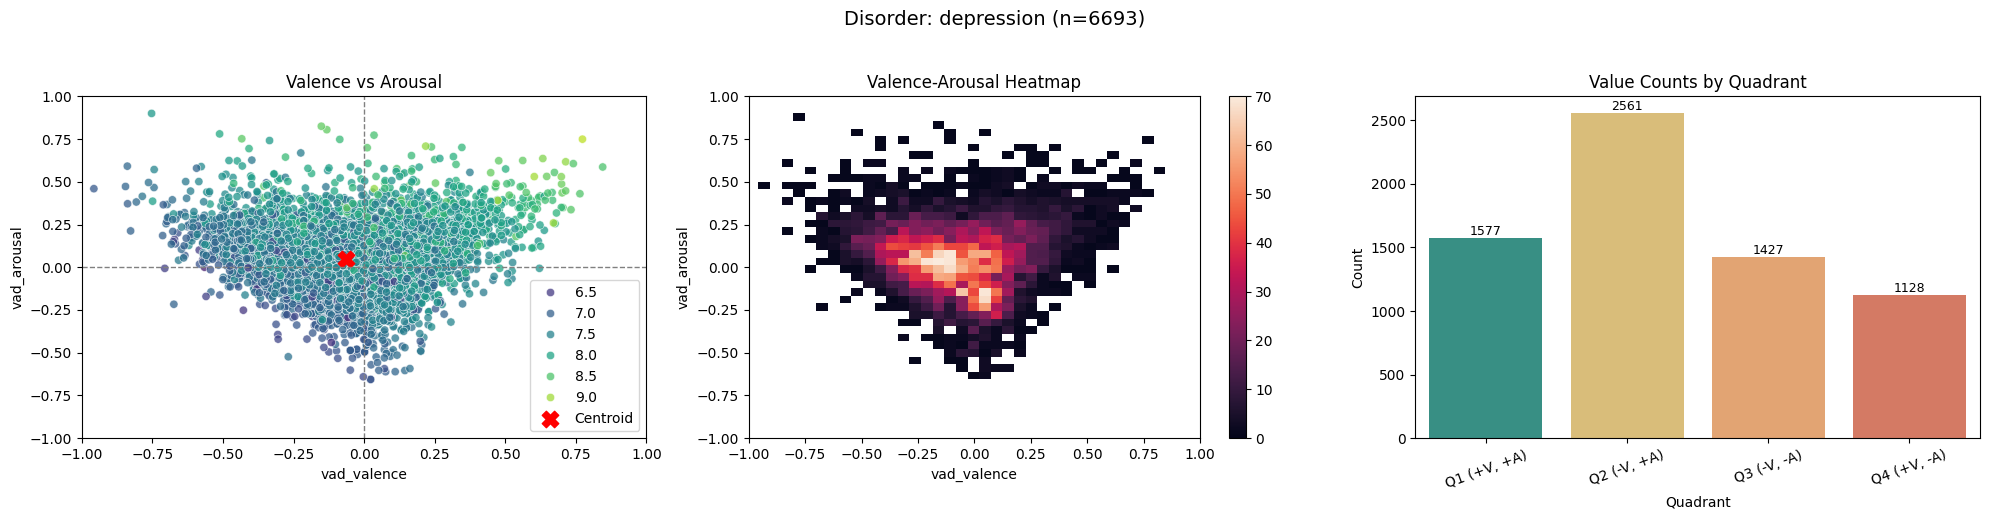

/tmp/ipykernel_2175047/3567209215.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


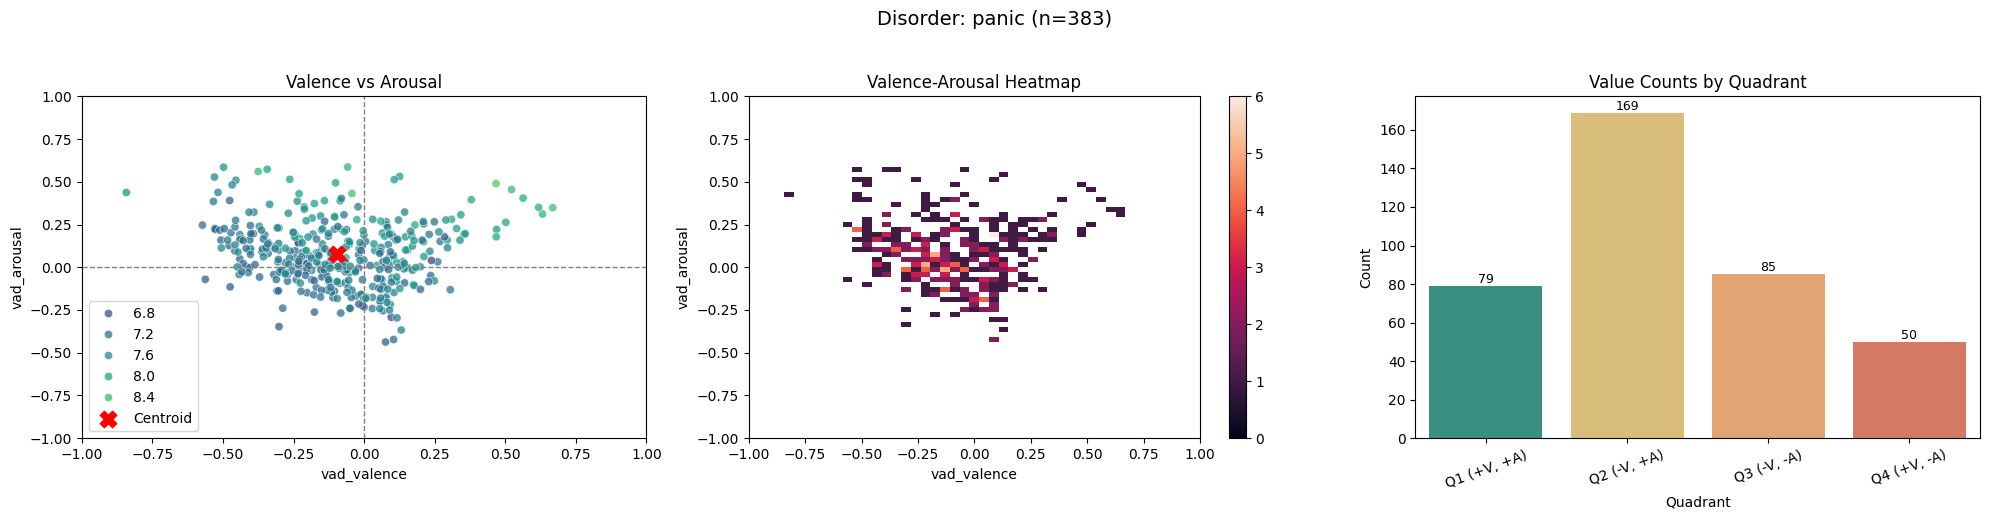

/tmp/ipykernel_2175047/3567209215.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


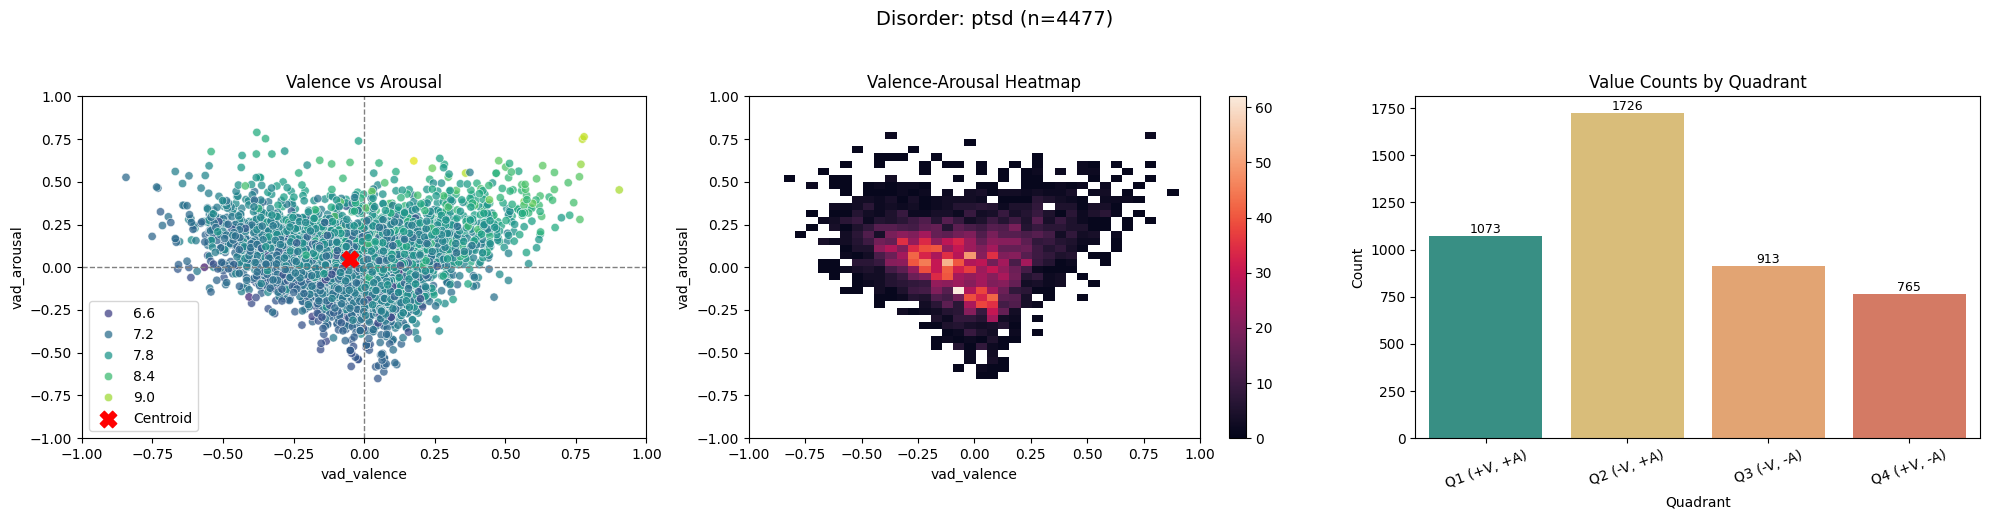

In [ ]:
plot_df = analysis_df.dropna(subset=['disorder', 'vad_valence', 'vad_arousal', 'va_distance']).copy()

summary_df = (
    plot_df
    .groupby('disorder')
    .agg(
        n=('disorder', 'size'),
        valence_mean=('vad_valence', 'mean'),
        valence_std=('vad_valence', 'std'),
        valence_skew=('vad_valence', 'skew'),
        arousal_mean=('vad_arousal', 'mean'),
        arousal_std=('vad_arousal', 'std'),
        arousal_skew=('vad_arousal', 'skew'),
        distance_mean=('va_distance', 'mean'),
        distance_std=('va_distance', 'std'),
        distance_skew=('va_distance', 'skew')
    )
    .sort_values('n', ascending=False)
)

print('Summary table per disorder:')
print(summary_df.round(4))

x_min, x_max = plot_df['vad_valence'].min(), plot_df['vad_valence'].max()
y_min, y_max = plot_df['vad_arousal'].min(), plot_df['vad_arousal'].max()
c_min, c_max = plot_df['va_distance'].min(), plot_df['va_distance'].max()

plot_df['quadrant'] = np.select(
    [
        (plot_df['vad_valence'] >= 0) & (plot_df['vad_arousal'] >= 0),
        (plot_df['vad_valence'] < 0) & (plot_df['vad_arousal'] >= 0),
        (plot_df['vad_valence'] < 0) & (plot_df['vad_arousal'] < 0),
        (plot_df['vad_valence'] >= 0) & (plot_df['vad_arousal'] < 0)
    ],
    ['Q1 (+V, +A)', 'Q2 (-V, +A)', 'Q3 (-V, -A)', 'Q4 (+V, -A)'],
    default='Other'
)

quadrant_order = ['Q1 (+V, +A)', 'Q2 (-V, +A)', 'Q3 (-V, -A)', 'Q4 (+V, -A)']

for disorder_name in sorted(plot_df['disorder'].unique()):
    subset = plot_df[plot_df['disorder'] == disorder_name].copy()

    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    fig.suptitle(f'Disorder: {disorder_name} (n={len(subset)})', fontsize=14, y=1.03)

    # Standardized scatter with shared hue scale
    sns.scatterplot(
        data=subset,
        x='vad_valence',
        y='vad_arousal',
        hue='va_distance',
        palette='viridis',
        hue_norm=(c_min, c_max),
        alpha=0.75,
        ax=axes[0]
    )
    axes[0].set_xlim(x_min, x_max)
    axes[0].set_ylim(y_min, y_max)
    axes[0].axvline(0, color='gray', linestyle='--', linewidth=1)
    axes[0].axhline(0, color='gray', linestyle='--', linewidth=1)
    axes[0].set_title('Valence vs Arousal')

    centroid_x = subset['vad_valence'].mean()
    centroid_y = subset['vad_arousal'].mean()
    axes[0].scatter(centroid_x, centroid_y, s=140, c='red', marker='X', label='Centroid')
    axes[0].legend(loc='best')

    sns.histplot(
        data=subset,
        x='vad_valence',
        y='vad_arousal',
        bins=35,
        cmap='rocket',
        cbar=True,
        ax=axes[1]
    )
    axes[1].set_xlim(x_min, x_max)
    axes[1].set_ylim(y_min, y_max)
    axes[1].set_title('Valence-Arousal Heatmap')

    quadrant_counts = subset['quadrant'].value_counts().reindex(quadrant_order, fill_value=0)
    sns.barplot(
        x=quadrant_counts.index,
        y=quadrant_counts.values,
        palette=['#2a9d8f', '#e9c46a', '#f4a261', '#e76f51'],
        ax=axes[2]
    )
    axes[2].set_title('Value Counts by Quadrant')
    axes[2].set_xlabel('Quadrant')
    axes[2].set_ylabel('Count')
    axes[2].tick_params(axis='x', rotation=20)

    for i, v in enumerate(quadrant_counts.values):
        axes[2].text(i, v, str(v), ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()

# Plots with the resampled dataset.

-> all the disorders have the same samples

Original counts per disorder:
disorder
anxiety        2963
bipolar        3184
borderline      677
control       33223
depression     6693
panic           383
ptsd           4477
Name: count, dtype: int64

Using target sample size per disorder: 383


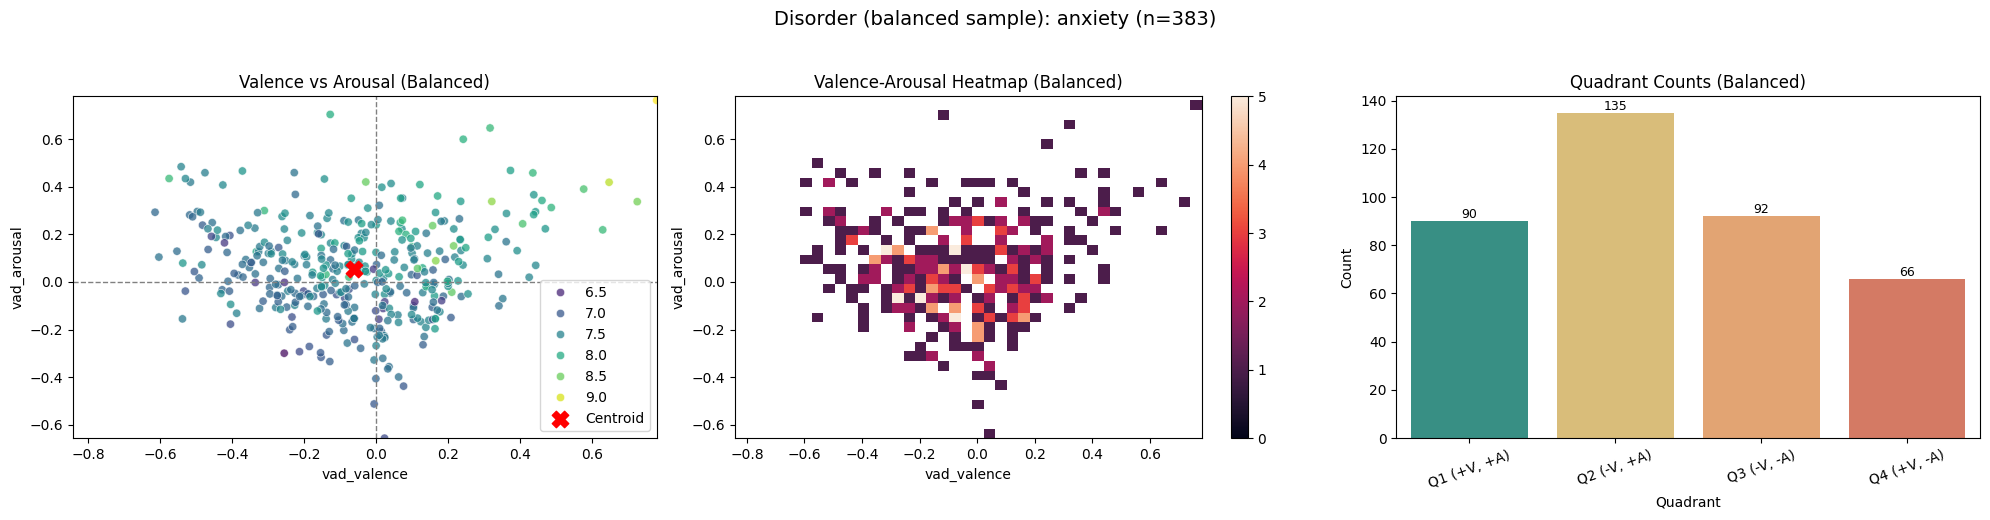

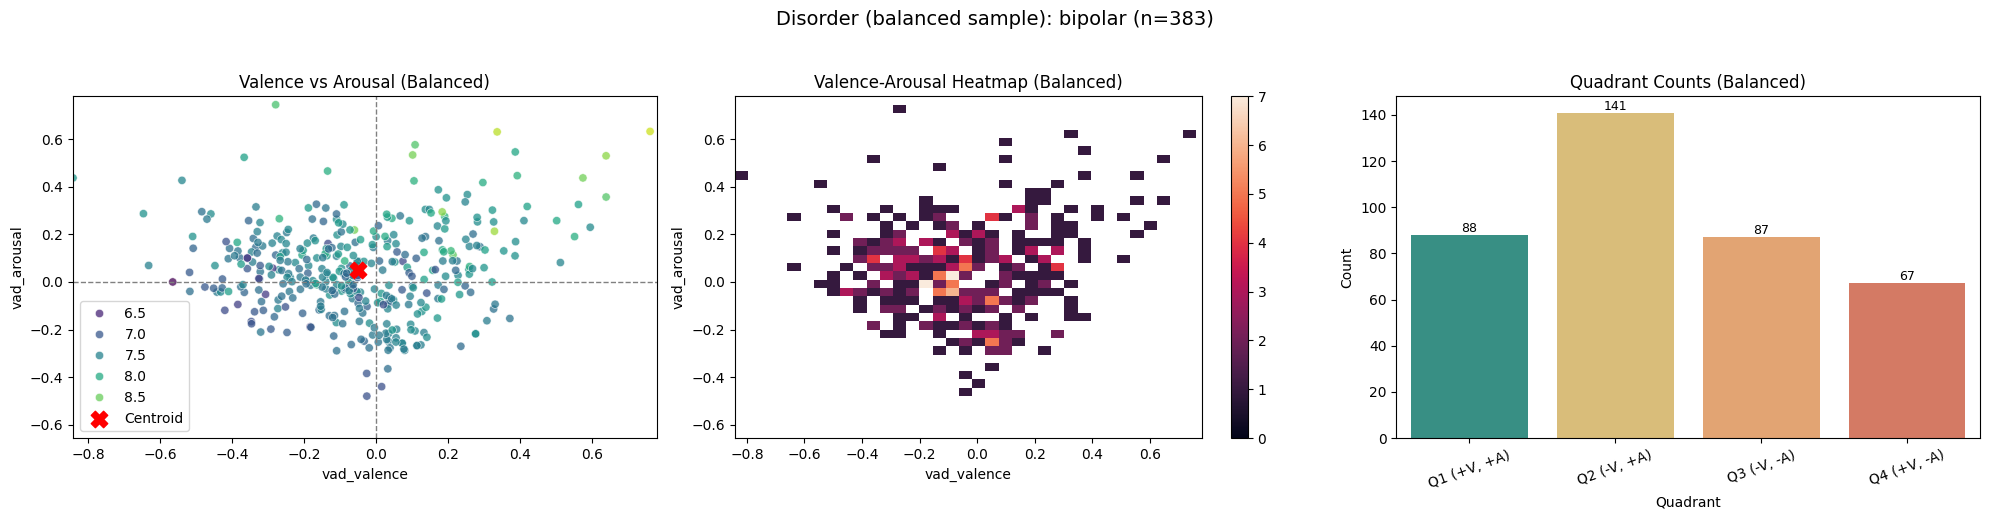

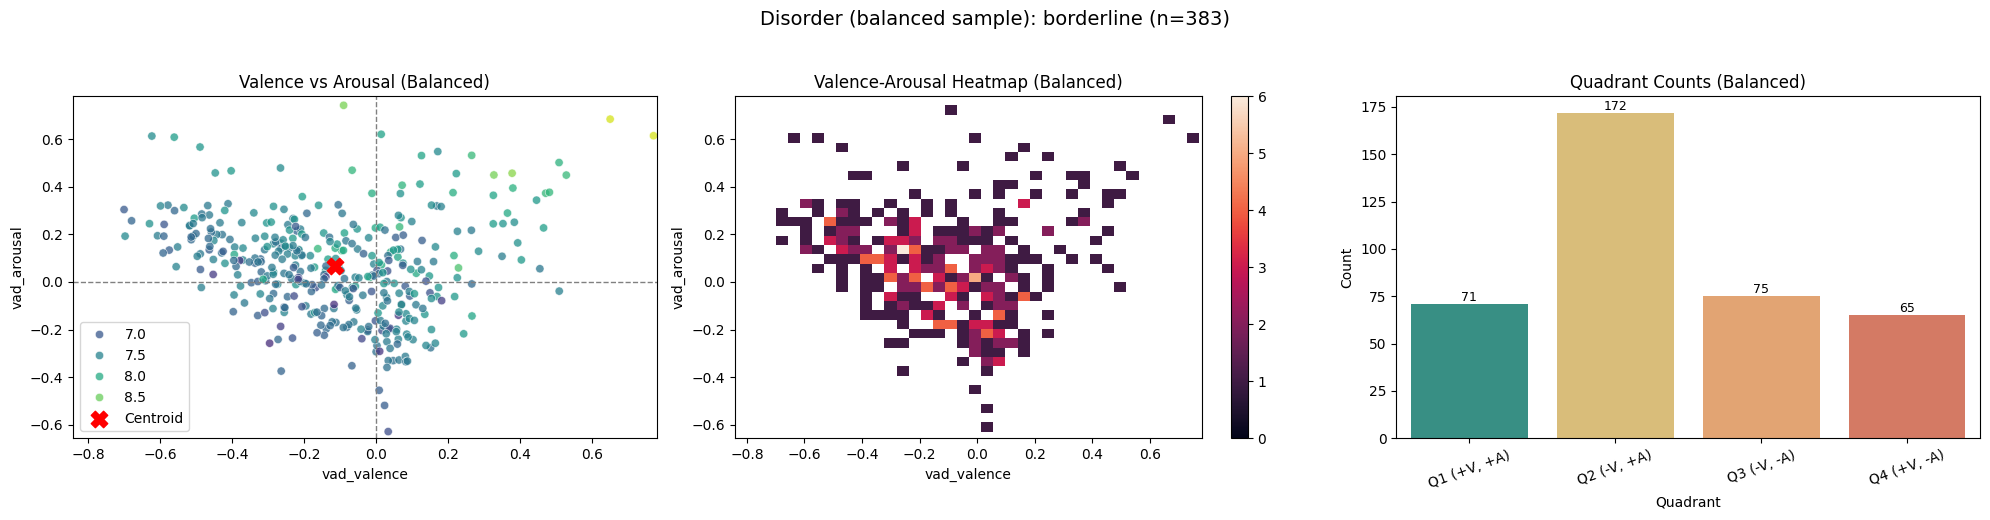

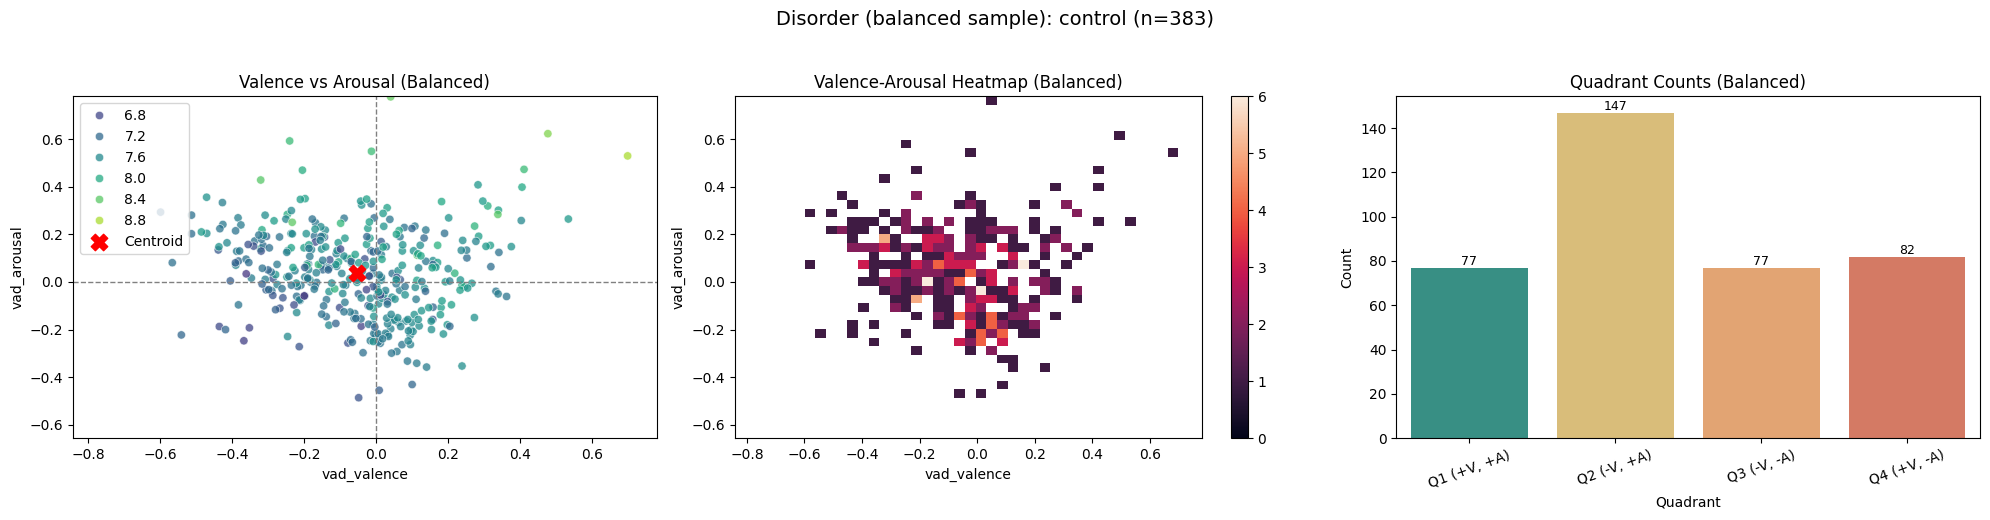

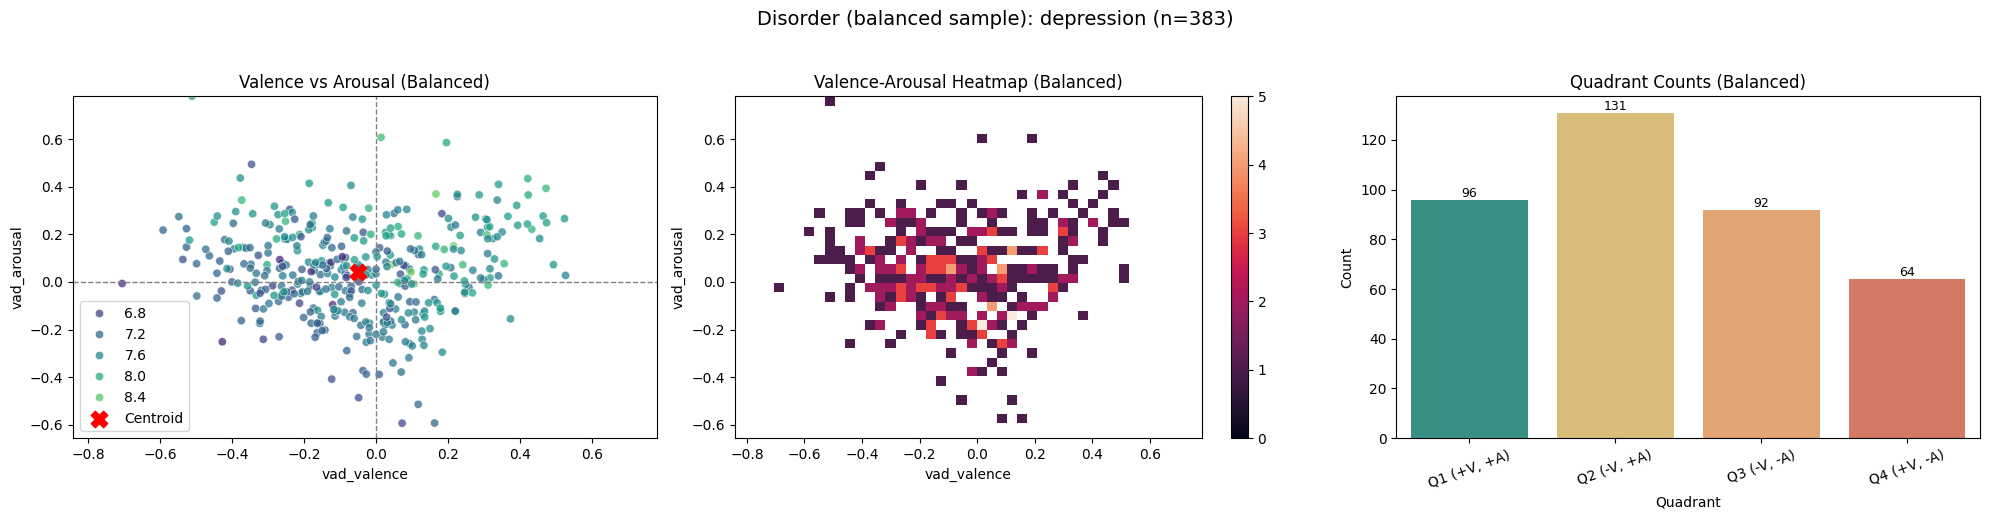

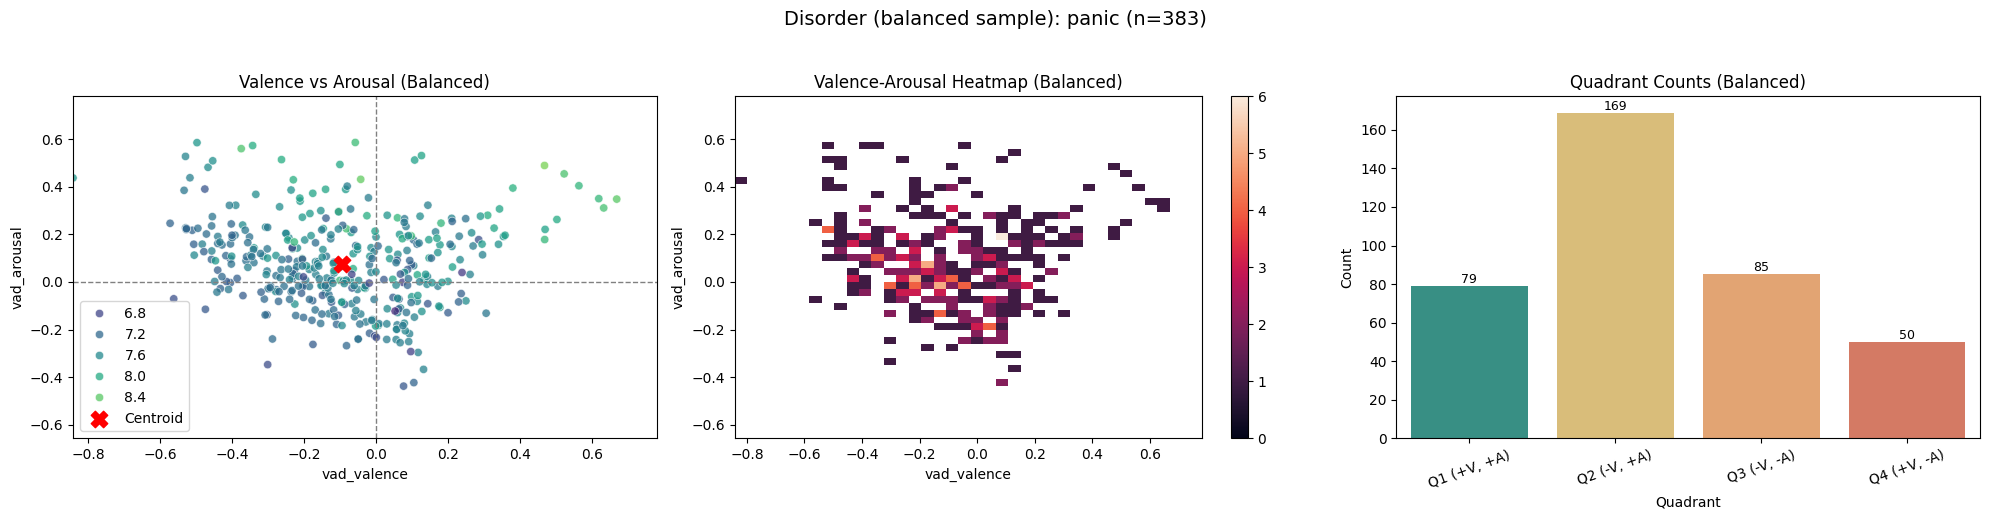

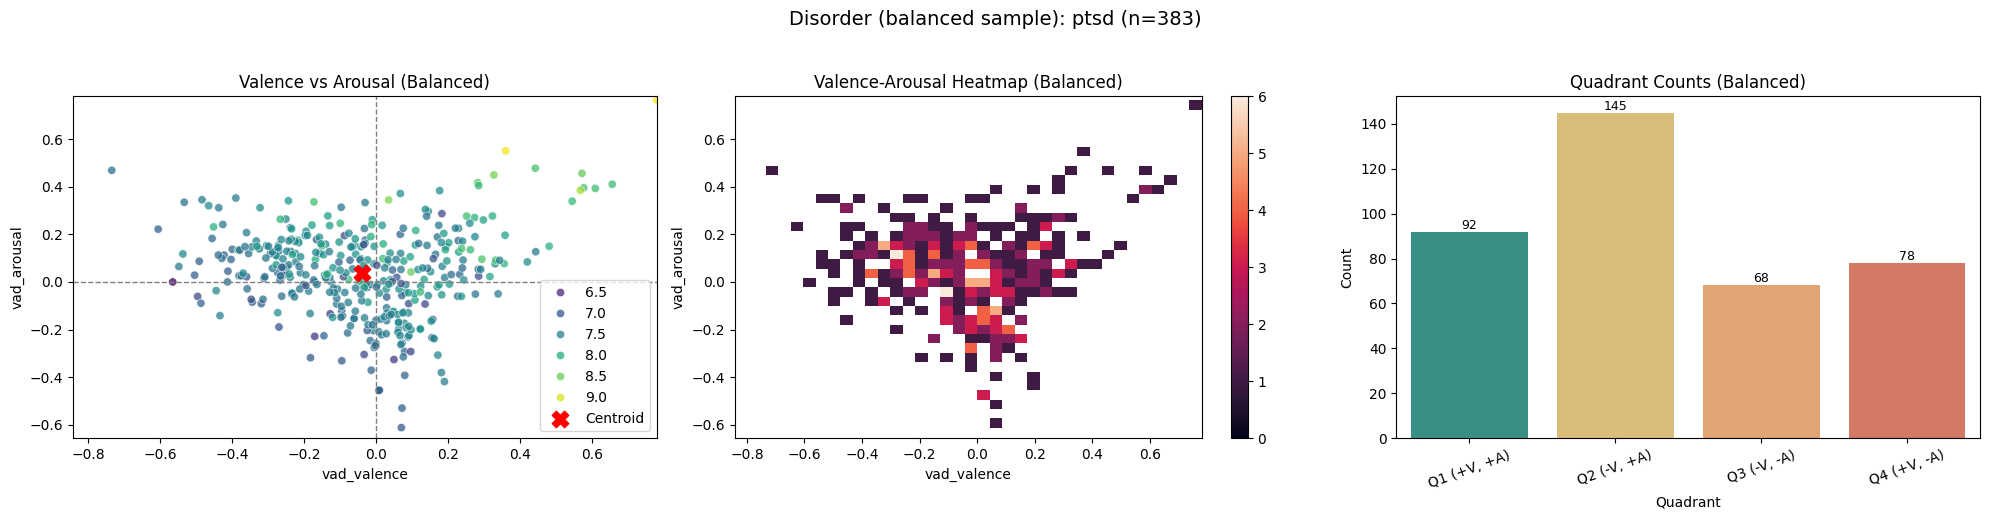

In [ ]:
resample_df = analysis_df.dropna(subset=['disorder', 'vad_valence', 'vad_arousal', 'va_distance']).copy()

disorder_counts = resample_df['disorder'].value_counts().sort_index()
target_n = disorder_counts.min()
print('Original counts per disorder:')
print(disorder_counts)
print(f'\nUsing target sample size per disorder: {target_n}')

balanced_df = (
    resample_df
    .groupby('disorder', group_keys=False)
    .sample(n=target_n, random_state=42, replace=False)
    .reset_index(drop=True)
)

balanced_df['quadrant'] = np.select(
    [
        (balanced_df['vad_valence'] >= 0) & (balanced_df['vad_arousal'] >= 0),
        (balanced_df['vad_valence'] < 0) & (balanced_df['vad_arousal'] >= 0),
        (balanced_df['vad_valence'] < 0) & (balanced_df['vad_arousal'] < 0),
        (balanced_df['vad_valence'] >= 0) & (balanced_df['vad_arousal'] < 0)
    ],
    ['Q1 (+V, +A)', 'Q2 (-V, +A)', 'Q3 (-V, -A)', 'Q4 (+V, -A)'],
    default='Other'
)
quadrant_order = ['Q1 (+V, +A)', 'Q2 (-V, +A)', 'Q3 (-V, -A)', 'Q4 (+V, -A)']
palette_map = {
    'Q1 (+V, +A)': '#2a9d8f',
    'Q2 (-V, +A)': '#e9c46a',
    'Q3 (-V, -A)': '#f4a261',
    'Q4 (+V, -A)': '#e76f51'
}

x_min_b, x_max_b = balanced_df['vad_valence'].min(), balanced_df['vad_valence'].max()
y_min_b, y_max_b = balanced_df['vad_arousal'].min(), balanced_df['vad_arousal'].max()
c_min_b, c_max_b = balanced_df['va_distance'].min(), balanced_df['va_distance'].max()

for disorder_name in sorted(balanced_df['disorder'].unique()):
    subset = balanced_df[balanced_df['disorder'] == disorder_name].copy()

    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    fig.suptitle(f'Disorder (balanced sample): {disorder_name} (n={len(subset)})', fontsize=14, y=1.03)


    sns.scatterplot(
        data=subset,
        x='vad_valence',
        y='vad_arousal',
        hue='va_distance',
        palette='viridis',
        hue_norm=(c_min_b, c_max_b),
        alpha=0.75,
        ax=axes[0]
    )
    axes[0].set_xlim(x_min_b, x_max_b)
    axes[0].set_ylim(y_min_b, y_max_b)
    axes[0].axvline(0, color='gray', linestyle='--', linewidth=1)
    axes[0].axhline(0, color='gray', linestyle='--', linewidth=1)
    axes[0].set_title('Valence vs Arousal (Balanced)')

    centroid_x = subset['vad_valence'].mean()
    centroid_y = subset['vad_arousal'].mean()
    axes[0].scatter(centroid_x, centroid_y, s=140, c='red', marker='X', label='Centroid')
    axes[0].legend(loc='best')

    sns.histplot(
        data=subset,
        x='vad_valence',
        y='vad_arousal',
        bins=35,
        cmap='rocket',
        cbar=True,
        ax=axes[1]
    )
    axes[1].set_xlim(x_min_b, x_max_b)
    axes[1].set_ylim(y_min_b, y_max_b)
    axes[1].set_title('Valence-Arousal Heatmap (Balanced)')

    quadrant_counts = subset['quadrant'].value_counts().reindex(quadrant_order, fill_value=0)
    quadrant_plot_df = quadrant_counts.rename_axis('quadrant').reset_index(name='count')
    sns.barplot(
        data=quadrant_plot_df,
        x='quadrant',
        y='count',
        hue='quadrant',
        palette=palette_map,
        legend=False,
        ax=axes[2]
    )
    axes[2].set_title('Quadrant Counts (Balanced)')
    axes[2].set_xlabel('Quadrant')
    axes[2].set_ylabel('Count')
    axes[2].tick_params(axis='x', rotation=20)

    for i, v in enumerate(quadrant_counts.values):
        axes[2].text(i, v, str(v), ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()

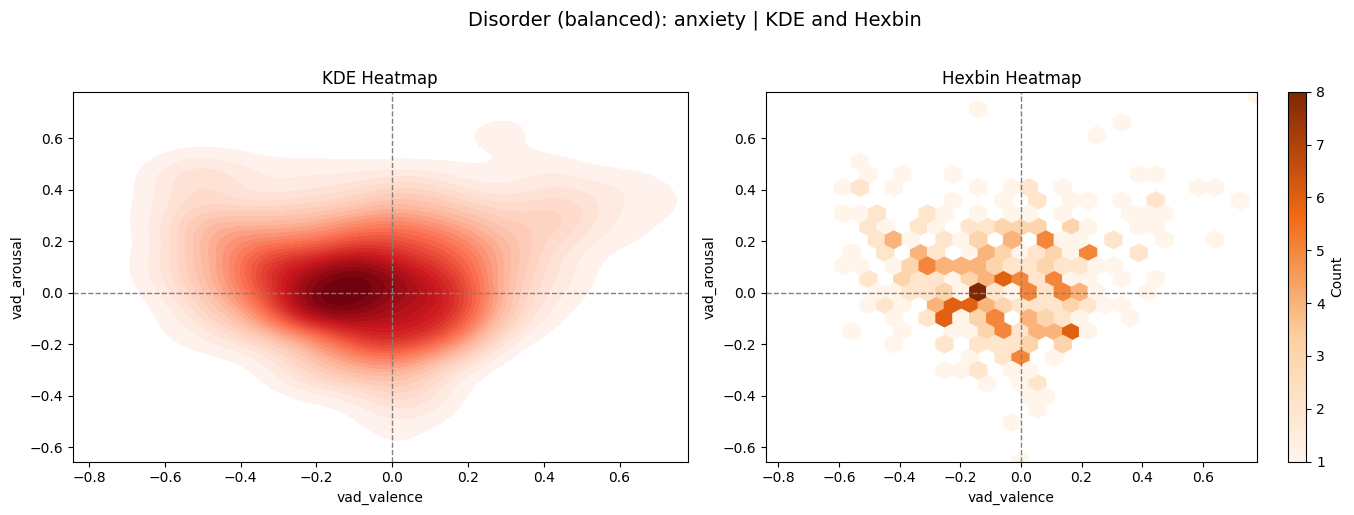

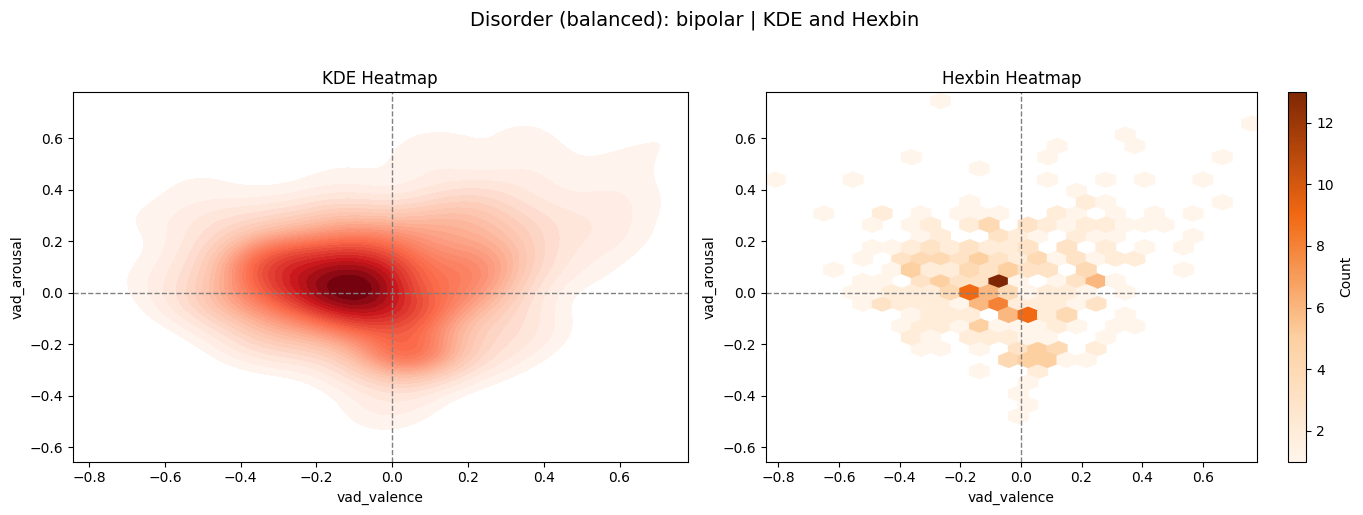

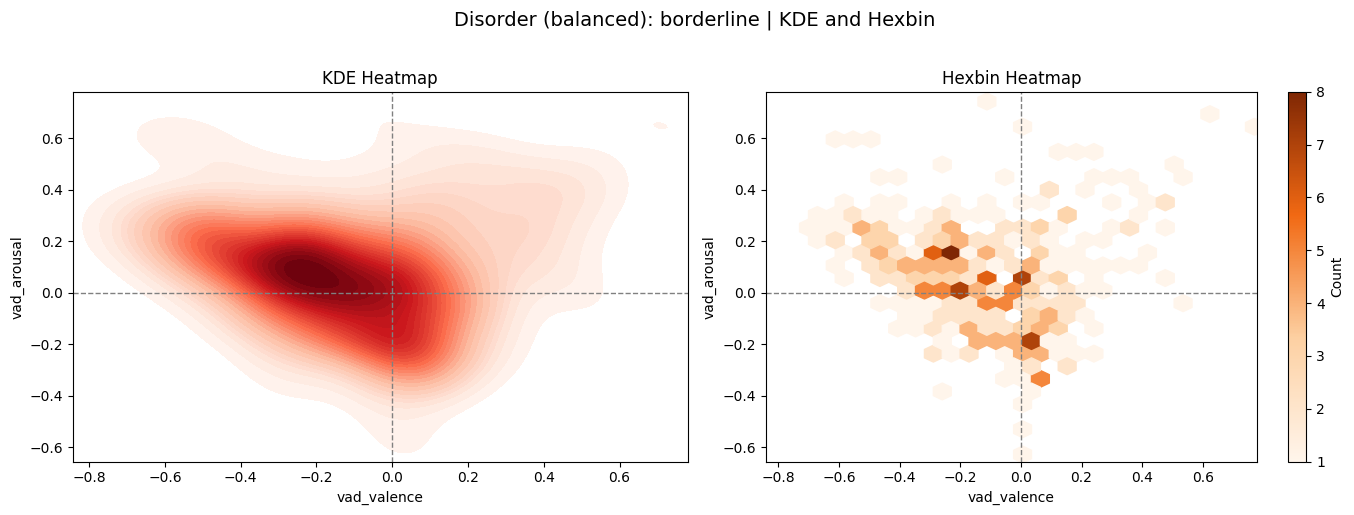

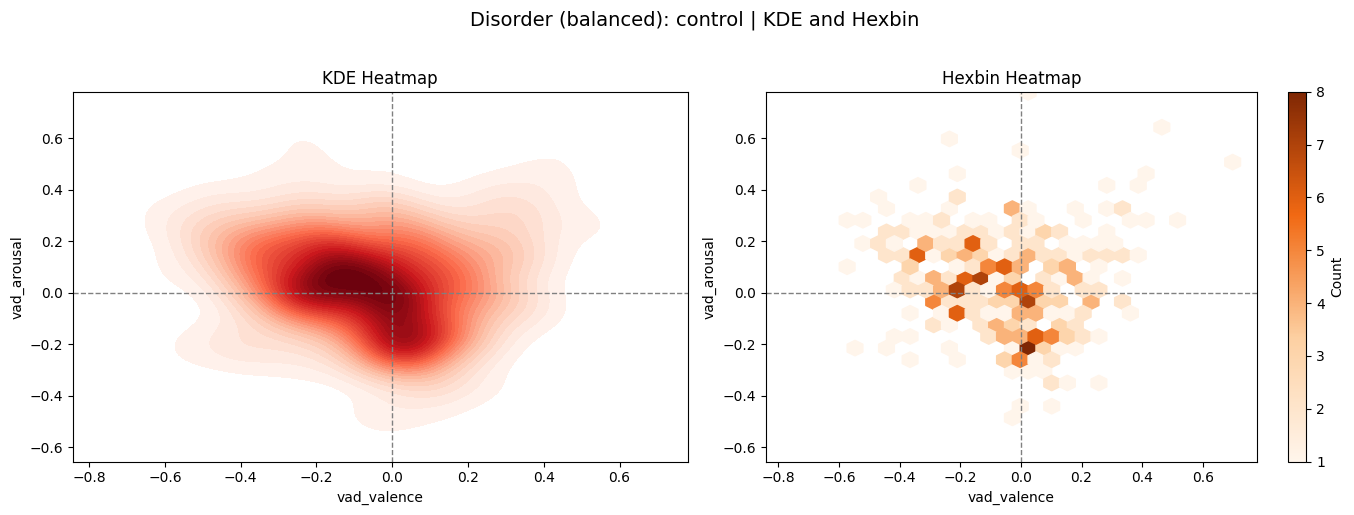

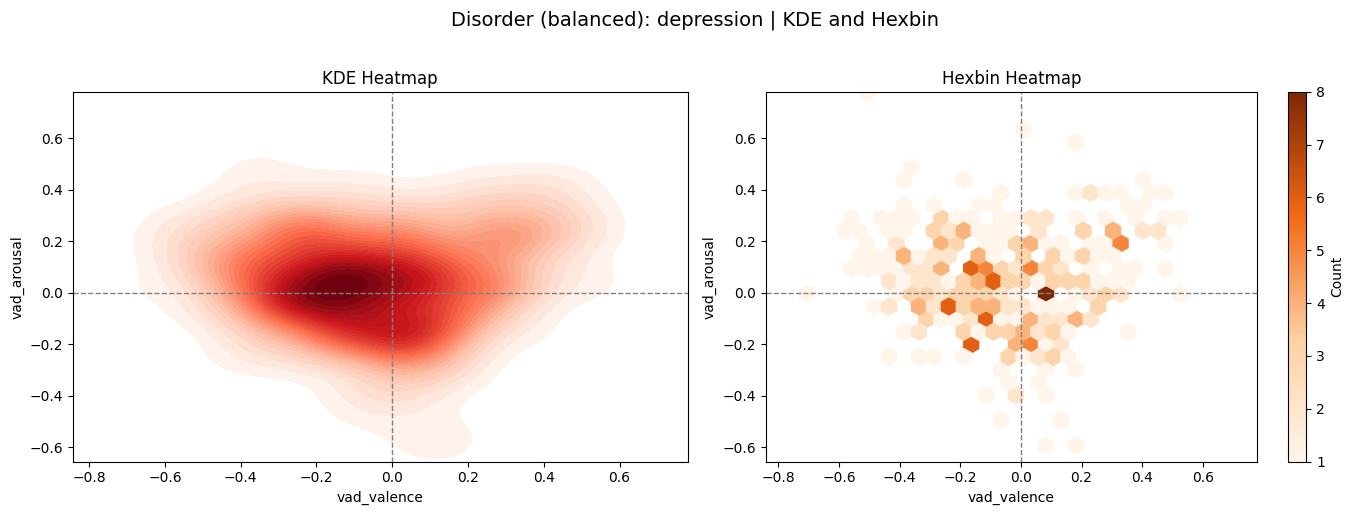

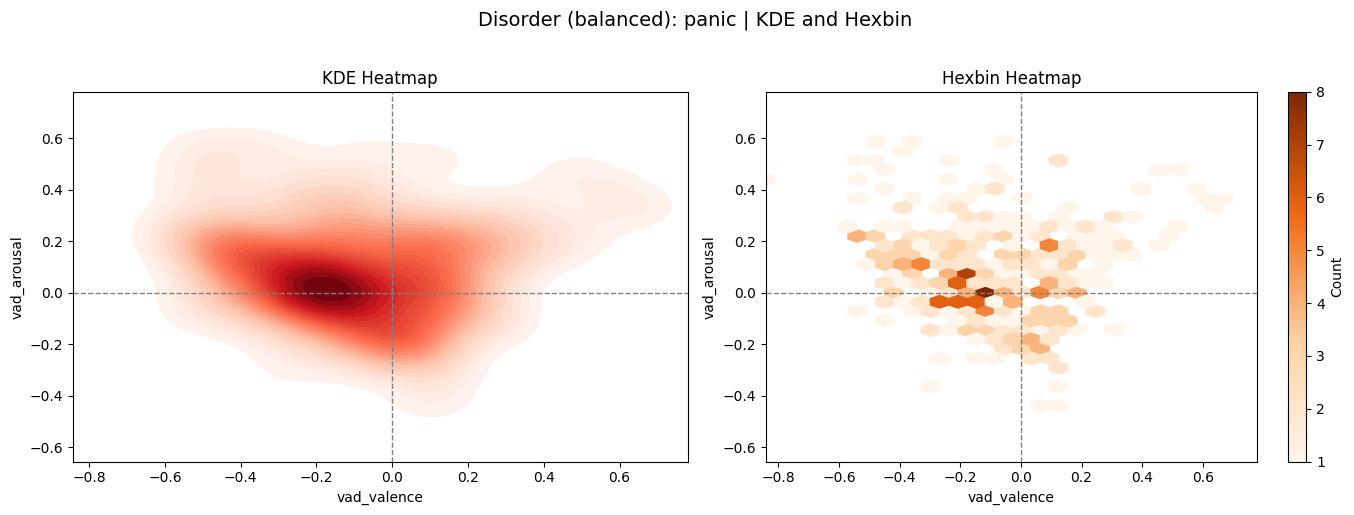

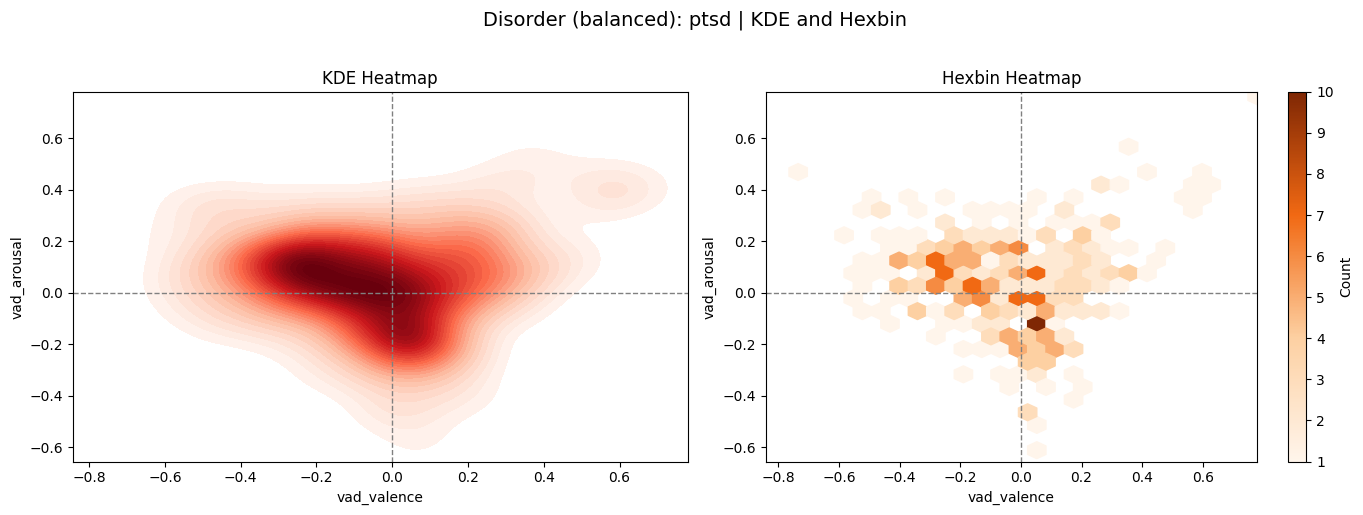

In [ ]:
from matplotlib.colors import LinearSegmentedColormap

if 'balanced_df' not in locals():
    tmp_df = analysis_df.dropna(subset=['disorder', 'vad_valence', 'vad_arousal', 'va_distance']).copy()
    n_min = tmp_df['disorder'].value_counts().min()
    balanced_df = (
        tmp_df
        .groupby('disorder', group_keys=False)
        .sample(n=n_min, random_state=42, replace=False)
        .reset_index(drop=True)
    )

x_min_k, x_max_k = balanced_df['vad_valence'].min(), balanced_df['vad_valence'].max()
y_min_k, y_max_k = balanced_df['vad_arousal'].min(), balanced_df['vad_arousal'].max()

kde_cmap = LinearSegmentedColormap.from_list(
    'kde_contrast',
    ['#fff5f0', '#fcbba1', '#fb6a4a', '#cb181d', '#67000d']
)
hex_cmap = LinearSegmentedColormap.from_list(
    'hex_warm', ['#fff5eb', '#fdd0a2', '#f16913', '#7f2704']
)

for disorder_name in sorted(balanced_df['disorder'].unique()):
    subset = balanced_df[balanced_df['disorder'] == disorder_name].copy()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Disorder (balanced): {disorder_name} | KDE and Hexbin', fontsize=14, y=1.02)

    # KDE density heatmap
    sns.kdeplot(
        data=subset,
        x='vad_valence',
        y='vad_arousal',
        fill=True,
        levels=30,
        thresh=0.03,
        cmap=kde_cmap,
        ax=axes[0]
    )
    axes[0].axvline(0, color='gray', linestyle='--', linewidth=1)
    axes[0].axhline(0, color='gray', linestyle='--', linewidth=1)
    axes[0].set_xlim(x_min_k, x_max_k)
    axes[0].set_ylim(y_min_k, y_max_k)
    axes[0].set_title('KDE Heatmap')
    axes[0].set_xlabel('vad_valence')
    axes[0].set_ylabel('vad_arousal')

    hb = axes[1].hexbin(
        subset['vad_valence'],
        subset['vad_arousal'],
        gridsize=25,
        cmap=hex_cmap,
        mincnt=1
    )
    axes[1].axvline(0, color='gray', linestyle='--', linewidth=1)
    axes[1].axhline(0, color='gray', linestyle='--', linewidth=1)
    axes[1].set_xlim(x_min_k, x_max_k)
    axes[1].set_ylim(y_min_k, y_max_k)
    axes[1].set_title('Hexbin Heatmap')
    axes[1].set_xlabel('vad_valence')
    axes[1].set_ylabel('vad_arousal')
    fig.colorbar(hb, ax=axes[1], label='Count')

    plt.tight_layout()
    plt.show()

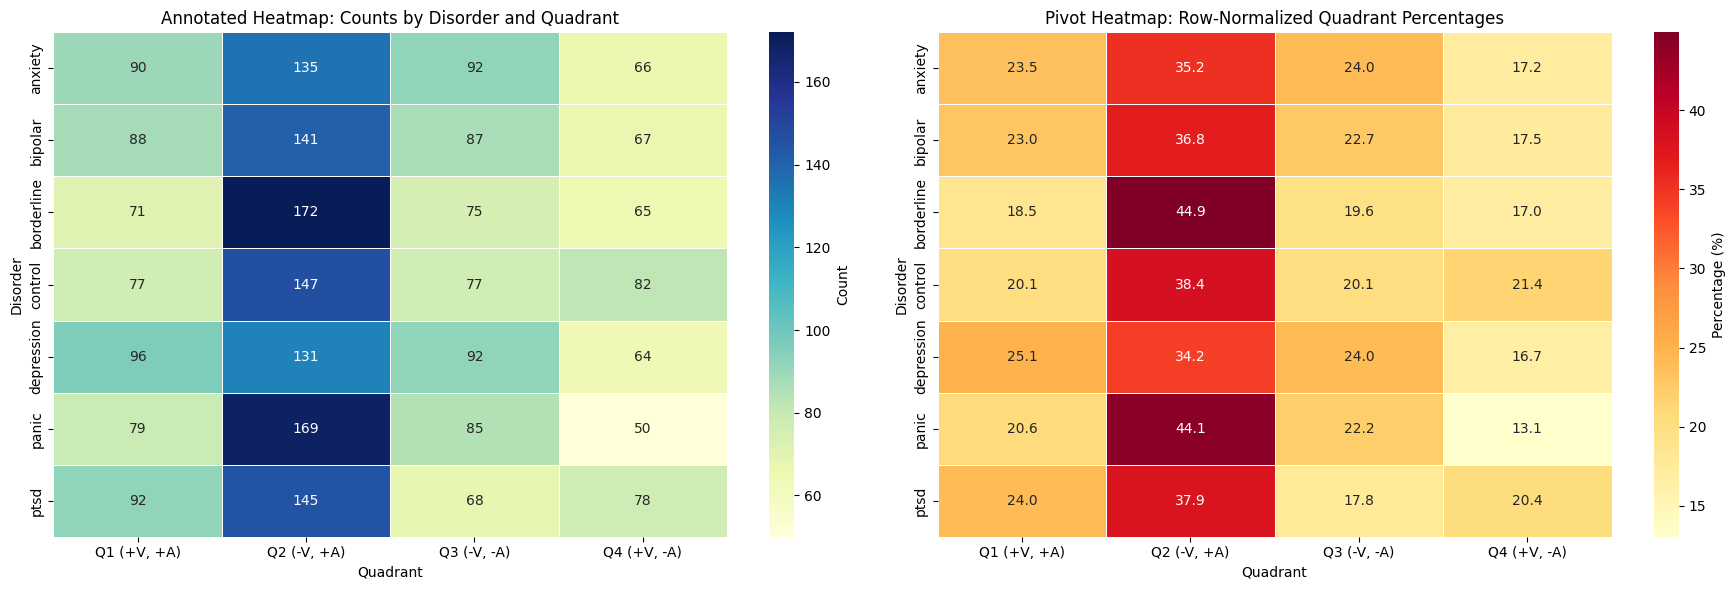

In [ ]:
if 'balanced_df' not in locals():
    tmp_df = analysis_df.dropna(subset=['disorder', 'vad_valence', 'vad_arousal']).copy()
    n_min = tmp_df['disorder'].value_counts().min()
    balanced_df = (
        tmp_df
        .groupby('disorder', group_keys=False)
        .sample(n=n_min, random_state=42, replace=False)
        .reset_index(drop=True)
    )

heat_df = balanced_df.copy()
if 'quadrant' not in heat_df.columns:
    heat_df['quadrant'] = np.select(
        [
            (heat_df['vad_valence'] >= 0) & (heat_df['vad_arousal'] >= 0),
            (heat_df['vad_valence'] < 0) & (heat_df['vad_arousal'] >= 0),
            (heat_df['vad_valence'] < 0) & (heat_df['vad_arousal'] < 0),
            (heat_df['vad_valence'] >= 0) & (heat_df['vad_arousal'] < 0)
        ],
        ['Q1 (+V, +A)', 'Q2 (-V, +A)', 'Q3 (-V, -A)', 'Q4 (+V, -A)'],
        default='Other'
    )

quadrant_order = ['Q1 (+V, +A)', 'Q2 (-V, +A)', 'Q3 (-V, -A)', 'Q4 (+V, -A)']
disorder_order = sorted(heat_df['disorder'].unique())

disorder_quadrant_counts = pd.crosstab(heat_df['disorder'], heat_df['quadrant'])
count_heatmap = disorder_quadrant_counts.reindex(index=disorder_order, columns=quadrant_order, fill_value=0)

pct_heatmap = count_heatmap.div(count_heatmap.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.heatmap(
    count_heatmap,
    annot=True,
    fmt='d',
    cmap='YlGnBu',
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Count'},
    ax=axes[0]
)
axes[0].set_title('Annotated Heatmap: Counts by Disorder and Quadrant')
axes[0].set_xlabel('Quadrant')
axes[0].set_ylabel('Disorder')

sns.heatmap(
    pct_heatmap,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd',
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Percentage (%)'},
    ax=axes[1]
)
axes[1].set_title('Pivot Heatmap: Row-Normalized Quadrant Percentages')
axes[1].set_xlabel('Quadrant')
axes[1].set_ylabel('Disorder')

plt.tight_layout()
plt.show()